In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import os
from voluntary_fixation.envs import TR, MOVIE_FPS, EYEMOVE_ROOT, SAVE_ROOT, SUBJECT_IDS

SAVE_ROOT = '../../' + SAVE_ROOT
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # TrueTypeフォントを埋め込む
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = ['Arial','DejaVu Sans']
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.unicode_minus'] = False  # マイナス符号の化け防止

# plt.rcParams['font.family'] = 'Times New Roman' # font familyの設定
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 20 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 17 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 17 # 軸だけ変更されます

In [2]:

iou_q = 0.5
saliency_TR_q = 0.7

# testデータにおける, gaze_shiftとsaliency_shiftの共起回数や、それぞれの発生回数
behavior_path = os.path.join(SAVE_ROOT, 'behavior','behaviors.csv')
behavior_df = pd.read_csv(behavior_path)
target_df = behavior_df.query(f'iou_q=={iou_q} and saliency_TR_q=={saliency_TR_q}')

total = np.array([int(i) for i in target_df['total'].item().replace('[','').replace(']','').replace(',', '').split(' ')])

sal = np.array([int(i) for i in target_df['sal'].item().replace('[','').replace(']','').replace(',', '').split(' ')])
not_sal = np.array([int(i) for i in target_df['not_sal'].item().replace('[','').replace(']','').replace(',', '').split(' ')]) #
eye = np.array([int(i) for i in target_df['eye'].item().replace('[','').replace(']','').replace(',', '').split(' ')])
joint_eye_sal = np.array([int(i) for i in target_df['joint_eye_sal'].item().replace('[','').replace(']','').replace(',', '').split(' ')])
joint_eye_not_sal = np.array([int(i) for i in target_df['joint_eye_not_sal'].item().replace('[','').replace(']','').replace(',', '').split(' ')])
prob_eye = eye/total
prob_inv_eye = joint_eye_sal/sal
prob_vol_eye = joint_eye_not_sal/not_sal
prob_sal = sal/total

print('Probability of Gaze Shift:', np.array(prob_eye))
print('Probability of Saliency Shift:', np.array(prob_sal))
print('Probability of Gaze Shift with Saliency Shift:', np.array(prob_inv_eye))
print('Probability of Gaze Shift without Saliency Shift:', np.array(prob_vol_eye))

prob_voluntary = np.array(prob_vol_eye)
prob_involuntary = np.array(prob_inv_eye)

print(prob_voluntary)
print(prob_involuntary)

Probability of Gaze Shift: [0.5031211  0.49299363 0.50636132 0.47399703 0.46134663 0.41304348
 0.47588832 0.43246592 0.46787709 0.52970297 0.51823899 0.4487021 ]
Probability of Saliency Shift: [0.34082397 0.34904459 0.34605598 0.32986627 0.34413965 0.342711
 0.34390863 0.34076828 0.33379888 0.34158416 0.34465409 0.33868974]
Probability of Gaze Shift with Saliency Shift: [0.56043956 0.54379562 0.50735294 0.51351351 0.47101449 0.45522388
 0.53874539 0.41818182 0.46443515 0.5942029  0.56569343 0.52189781]
Probability of Gaze Shift without Saliency Shift: [0.36971831 0.37142857 0.40659341 0.3976378  0.36140351 0.37090909
 0.35740072 0.41034483 0.37262357 0.45296167 0.40072202 0.29655172]
[0.36971831 0.37142857 0.40659341 0.3976378  0.36140351 0.37090909
 0.35740072 0.41034483 0.37262357 0.45296167 0.40072202 0.29655172]
[0.56043956 0.54379562 0.50735294 0.51351351 0.47101449 0.45522388
 0.53874539 0.41818182 0.46443515 0.5942029  0.56569343 0.52189781]


In [3]:
# FC (per-region delay = 各regionが初めて有意になった時刻)
#   37:R-SPL (td2 / 4s), 18:L-ACC/MPFC (td-1 / -2s), 35:R-LTL (td0 / 0s), 6:L-PCL/MC (td1 / 2s)
fc37 = np.load('fc-src36-tgt37-sd-1-td2-iq0.5-sq0.7-nbo.npy')
fc18 = np.load('fc-src36-tgt18-sd-1-td-1-iq0.5-sq0.7-nbo.npy')
fc35 = np.load('fc-src36-tgt35-sd-1-td0-iq0.5-sq0.7-nbo.npy')
fc6  = np.load('fc-src36-tgt6-sd-1-td1-iq0.5-sq0.7-nbo.npy')

In [4]:
# regression
def regression(x, y):
    reg = LinearRegression().fit(x, y)
    return reg.coef_[0], reg.intercept_[0]

/home/kazu/shared_response/figures/fig5/FC_vs_prob_eye_voluntary.pdf


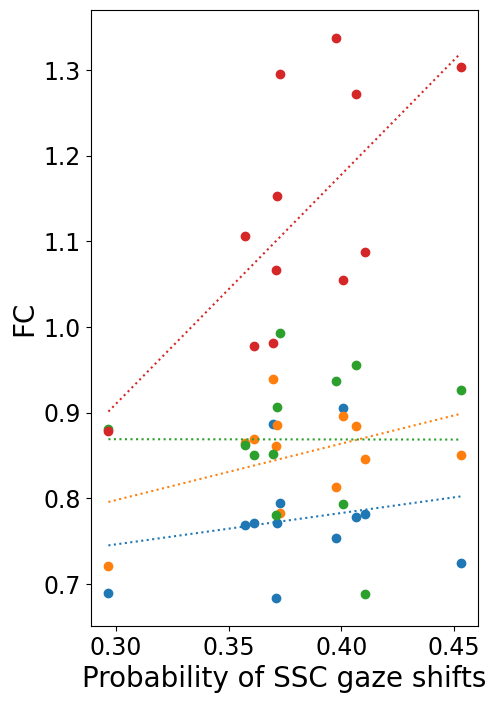

In [5]:
fig = plt.figure(figsize=(5,8))
plt.scatter(prob_voluntary, fc18, label='L-ACC/MPFC')
a, b = regression(prob_voluntary[:,np.newaxis], fc18[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc6, label='L-PCL/MC')
a, b = regression(prob_voluntary[:,np.newaxis], fc6[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc35, label='R-LTL')
a, b = regression(prob_voluntary[:,np.newaxis], fc35[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc37, label='R-SPL')
a, b = regression(prob_voluntary[:,np.newaxis], fc37[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.xlabel('Probability of SSC gaze shifts')
plt.ylabel('FC')
# plt.legend(bbox_to_anchor=(0, -0.25), loc='upper left', borderaxespad=0, fontsize=15)
savepath = os.path.join('figures', 'fig5', 'FC_vs_prob_eye_voluntary.pdf')
os.makedirs(os.path.dirname(savepath), exist_ok=True); plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)

/home/kazu/shared_response/figures/fig5/FC_vs_prob_eye_involuntary.pdf


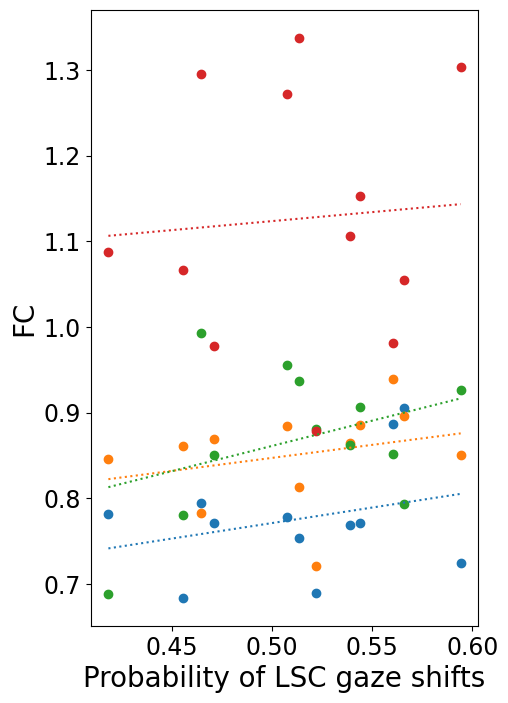

In [6]:
fig = plt.figure(figsize=(5,8))
plt.scatter(prob_involuntary, fc18, label='L-ACC/MPFC')
a, b = regression(prob_involuntary[:,np.newaxis], fc18[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc6, label='L-PCL/MC')
a, b = regression(prob_involuntary[:,np.newaxis], fc6[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc35, label='R-LTL')
a, b = regression(prob_involuntary[:,np.newaxis], fc35[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc37, label='R-SPL')
a, b = regression(prob_involuntary[:,np.newaxis], fc37[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.xlabel('Probability of LSC gaze shifts')
plt.ylabel('FC')
# plt.legend(bbox_to_anchor=(0, -0.25), loc='upper left', borderaxespad=0, fontsize=15)
savepath = os.path.join('figures', 'fig5', 'FC_vs_prob_eye_involuntary.pdf')
os.makedirs(os.path.dirname(savepath), exist_ok=True); plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import os
from voluntary_fixation.envs import TR, MOVIE_FPS, EYEMOVE_ROOT, SAVE_ROOT, SUBJECT_IDS

SAVE_ROOT = '../../' + SAVE_ROOT
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # TrueTypeフォントを埋め込む
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = ['Arial','DejaVu Sans']
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.unicode_minus'] = False  # マイナス符号の化け防止

# plt.rcParams['font.family'] = 'Times New Roman' # font familyの設定
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 20 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 20 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 20 # 軸だけ変更されます

/home/kazu/shared_response/figures/fig5_small/FC_vs_prob_eye_voluntary.pdf
/home/kazu/shared_response/figures/fig5_small/FC_vs_prob_eye_involuntary.pdf


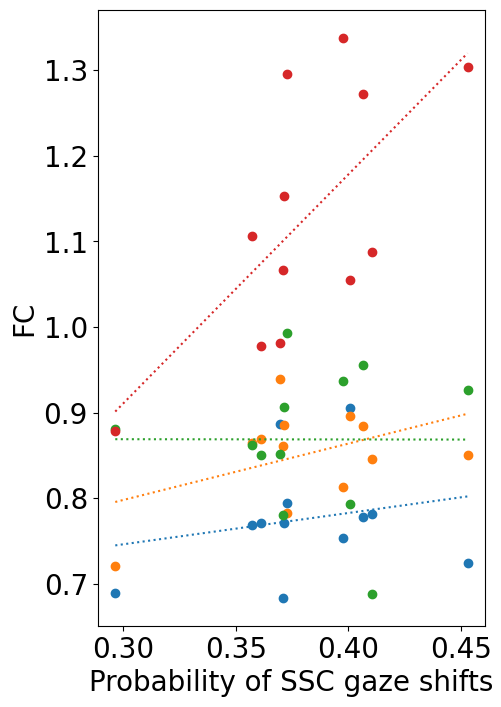

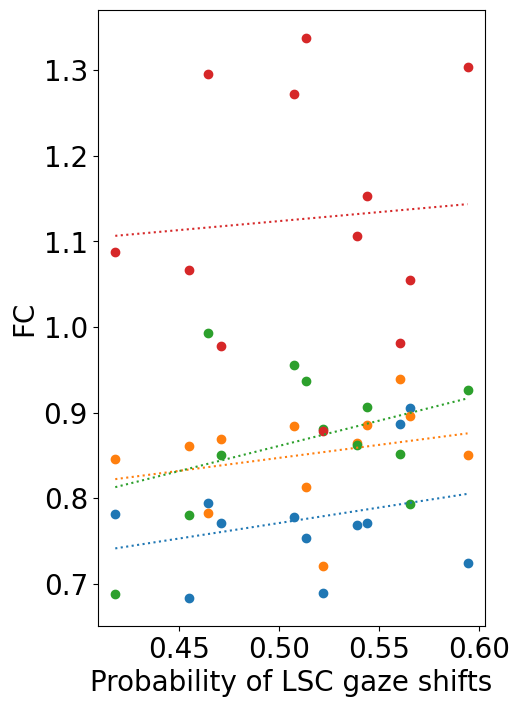

In [8]:
fig = plt.figure(figsize=(5,8))
plt.scatter(prob_voluntary, fc18, label='L-ACC/MPFC')
a, b = regression(prob_voluntary[:,np.newaxis], fc18[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc6, label='L-PCL/MC')
a, b = regression(prob_voluntary[:,np.newaxis], fc6[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc35, label='R-LTL')
a, b = regression(prob_voluntary[:,np.newaxis], fc35[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc37, label='R-SPL')
a, b = regression(prob_voluntary[:,np.newaxis], fc37[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.xlabel('Probability of SSC gaze shifts')
plt.ylabel('FC')
# plt.legend(bbox_to_anchor=(0, -0.25), loc='upper left', borderaxespad=0, fontsize=15)
savepath = os.path.join('figures', 'fig5_small', 'FC_vs_prob_eye_voluntary.pdf')
os.makedirs(os.path.dirname(savepath), exist_ok=True); plt.savefig(savepath, bbox_inches='tight', dpi=300)

print(savepath)
fig = plt.figure(figsize=(5,8))
plt.scatter(prob_involuntary, fc18, label='L-ACC/MPFC')
a, b = regression(prob_involuntary[:,np.newaxis], fc18[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc6, label='L-PCL/MC')
a, b = regression(prob_involuntary[:,np.newaxis], fc6[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc35, label='R-LTL')
a, b = regression(prob_involuntary[:,np.newaxis], fc35[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc37, label='R-SPL')
a, b = regression(prob_involuntary[:,np.newaxis], fc37[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.xlabel('Probability of LSC gaze shifts')
plt.ylabel('FC')
# plt.legend(bbox_to_anchor=(0, -0.25), loc='upper left', borderaxespad=0, fontsize=15)
savepath = os.path.join('figures', 'fig5_small', 'FC_vs_prob_eye_involuntary.pdf')
os.makedirs(os.path.dirname(savepath), exist_ok=True); plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)

In [9]:
prob_voluntary = np.array(prob_vol_eye)
prob_involuntary = np.array(prob_inv_eye)

In [10]:
# ========== Correlation jackknife (leave-one-subject-out r) ==========
# N=12 では1〜2点のレバレッジで r が動く。各被験者を1人ずつ除いて r を再計算し範囲を見る。
#   r が 0.55〜0.75 に収まる -> 相関は頑健 / r が 0.3 台まで落ちる被験者がいる -> 脆い。
from scipy.stats import pearsonr

fc_by_region = {'R-SPL': fc37, 'L-ACC/MPFC': fc18, 'R-LTL': fc35, 'L-PCL/MC': fc6}
for cond, p in [('SSC', prob_voluntary), ('LSC', prob_involuntary)]:
    print(f'===== {cond}: jackknife of Pearson r =====')
    for name, fc in fc_by_region.items():
        r_full = pearsonr(fc, p)[0]
        r_loo = np.array([pearsonr(np.delete(fc, i), np.delete(p, i))[0] for i in range(len(p))])
        i_min = int(r_loo.argmin())
        print(f'  {name:11s}: r_full={r_full:+.3f}  LOO r in [{r_loo.min():+.3f}, {r_loo.max():+.3f}]'
              f'  (most influential: drop sub-{SUBJECT_IDS[i_min]} -> r={r_loo.min():+.3f})')
    print()

===== SSC: jackknife of Pearson r =====
  R-SPL      : r_full=+0.684  LOO r in [+0.520, +0.761]  (most influential: drop sub-19 -> r=+0.520)
  L-ACC/MPFC : r_full=+0.209  LOO r in [-0.117, +0.459]  (most influential: drop sub-19 -> r=-0.117)
  R-LTL      : r_full=-0.001  LOO r in [-0.166, +0.228]  (most influential: drop sub-17 -> r=-0.166)
  L-PCL/MC   : r_full=+0.438  LOO r in [-0.129, +0.555]  (most influential: drop sub-19 -> r=-0.129)

===== LSC: jackknife of Pearson r =====
  R-SPL      : r_full=+0.074  LOO r in [-0.138, +0.201]  (most influential: drop sub-17 -> r=-0.138)
  L-ACC/MPFC : r_full=+0.283  LOO r in [+0.116, +0.479]  (most influential: drop sub-18 -> r=+0.116)
  R-LTL      : r_full=+0.361  LOO r in [-0.038, +0.585]  (most influential: drop sub-15 -> r=-0.038)
  L-PCL/MC   : r_full=+0.277  LOO r in [+0.163, +0.456]  (most influential: drop sub-01 -> r=+0.163)



In [11]:
# ========== Full-sample (N=12) Pearson & Spearman correlation ==========
# レバレッジ/線形性の仮定に依存しないか確認するため、順位相関(Spearman)も併記する。
from scipy.stats import pearsonr, spearmanr

fc_by_region = {'R-SPL': fc37, 'L-ACC/MPFC': fc18, 'R-LTL': fc35, 'L-PCL/MC': fc6}
for cond, p in [('SSC', prob_voluntary), ('LSC', prob_involuntary)]:
    print(f'===== {cond} (N=12) =====')
    for name, fc in fc_by_region.items():
        pr, pp = pearsonr(fc, p)
        sr, sp = spearmanr(fc, p)
        print(f'  {name:11s}: Pearson r={pr:+.3f} (p={pp:.4f})   Spearman rho={sr:+.3f} (p={sp:.4f})')
    print()

===== SSC (N=12) =====
  R-SPL      : Pearson r=+0.684 (p=0.0141)   Spearman rho=+0.622 (p=0.0307)
  L-ACC/MPFC : Pearson r=+0.209 (p=0.5154)   Spearman rho=+0.252 (p=0.4299)
  R-LTL      : Pearson r=-0.001 (p=0.9970)   Spearman rho=+0.154 (p=0.6331)
  L-PCL/MC   : Pearson r=+0.438 (p=0.1544)   Spearman rho=+0.007 (p=0.9828)

===== LSC (N=12) =====
  R-SPL      : Pearson r=+0.074 (p=0.8198)   Spearman rho=+0.035 (p=0.9141)
  L-ACC/MPFC : Pearson r=+0.283 (p=0.3724)   Spearman rho=+0.084 (p=0.7954)
  R-LTL      : Pearson r=+0.361 (p=0.2488)   Spearman rho=+0.175 (p=0.5868)
  L-PCL/MC   : Pearson r=+0.277 (p=0.3832)   Spearman rho=+0.448 (p=0.1446)

